<a href="https://colab.research.google.com/github/Dev-Panchal1/LD6051_ML_Group_Project_Student-Performance/blob/main/LD6051_ML_Group_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="red">**LD6051_ML_Group_Project_Predicting Student Academic Performance**</font>


### <font color="blue">**1. The Imports - Libraries**</font>

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Pre-processing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# One seed reused everywhere, so results are reproducible
RANDOM_STATE = 42

sns.set_theme(style="whitegrid")
print("Libraries imported successfully.")

Libraries imported successfully.


### <font color="blue">**2. Upload The Dataset**</font>

<font color="orange">The dataset `StudentPerformanceFactors.csv` contains 6,607 student records
with 19 input features and one target column, `Exam_Score`.
Source: Kaggle - Student Performance Factors.</font>

In [2]:
try:
    from google.colab import files
    uploaded = files.upload()          # select StudentPerformanceFactors.csv
    CSV_PATH = list(uploaded.keys())[0]
except (ImportError, ModuleNotFoundError):
    CSV_PATH = "StudentPerformanceFactors.csv"

df = pd.read_csv(CSV_PATH)
print(f"Loaded: {CSV_PATH}")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Saving StudentPerformanceFactors.csv to StudentPerformanceFactors.csv
Loaded: StudentPerformanceFactors.csv
Shape: 6607 rows × 20 columns


### <font color="Blue">**3. EDA (Exploratory Data Analysis)**</font>


### <font color="orange">3.1 The Dataset and Features</font>
##### <font color="orange">Before the modelling, the structure, data types & summary statistics of the dataset are examined to confirm it loaded correctly and to identify any quality issues that need attention.</font>

In [3]:
# Top 5 rows to inspect
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
# To identify Colomn Names
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}\n")
print(df.columns.tolist())

Rows: 6607
Columns: 20

['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']


In [5]:
# Basic information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [6]:
# Data types & Missing values
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values per column:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

Duplicate rows: 0


In [7]:
# Summary of Statistical info
df.describe().round(2)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00
mean,19.98,79.98,7.03,75.07,1.49,2.97,67.24
std,5.99,11.55,1.47,14.40,1.23,1.03,3.89
min,1.00,60.00,4.00,50.00,0.00,0.00,55.00
25%,16.00,70.00,6.00,63.00,1.00,2.00,65.00
50%,20.00,80.00,7.00,75.00,1.00,3.00,67.00
75%,24.00,90.00,8.00,88.00,2.00,4.00,69.00
max,44.00,100.00,10.00,100.00,8.00,6.00,101.00


### <font color="orange">3.2 Data Analysis and Visualization</font>
##### <font color="orange">Three visualisations are used to understand the data before modelling.</font>
##### <font color="orange">1. Histograms of the numeric features.</font>
##### <font color="orange">2. Boxplots of exam score across key categorical.</font>
##### <font color="orange">3. A correlation heatmap.</font>

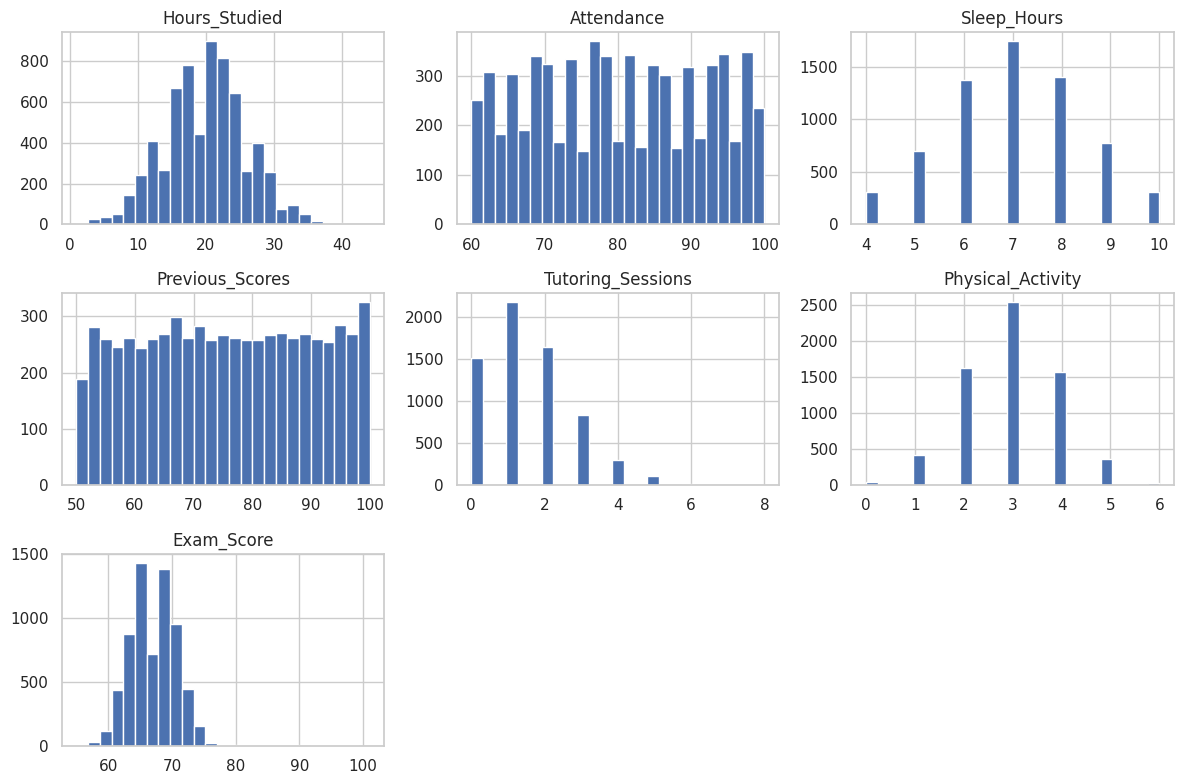

In [8]:
# Histograms/Distribution of numerical features
num_cols = df.select_dtypes(include=np.number).columns.tolist()

df[num_cols].hist(bins=25, figsize=(12, 8), color="#4C72B0", edgecolor="white")
plt.tight_layout()
plt.show()

/tmp/ipykernel_3619/346097446.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=c, y="Exam_Score", data=df, order=order, ax=ax, palette="Blues")
/tmp/ipykernel_3619/346097446.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=c, y="Exam_Score", data=df, order=order, ax=ax, palette="Blues")
/tmp/ipykernel_3619/346097446.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=c, y="Exam_Score", data=df, order=order, ax=ax, palette="Blues")
/tmp/ipykernel_3619/346097446.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is de

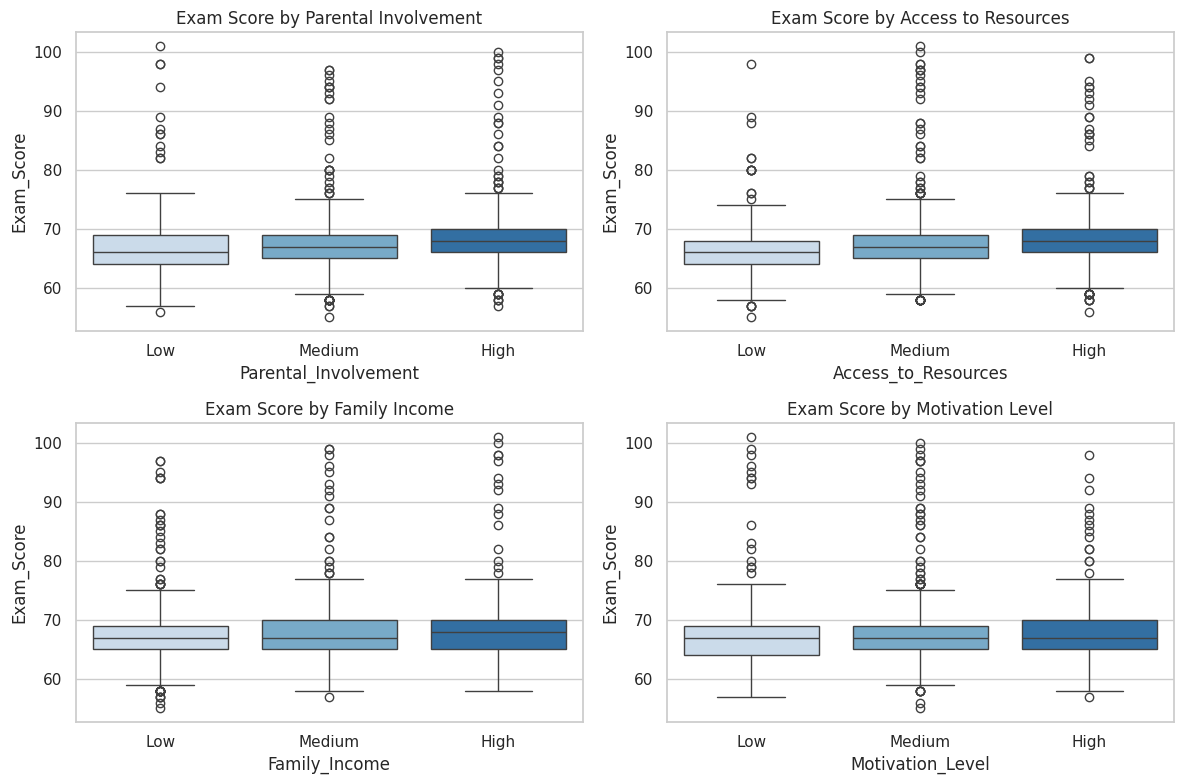

In [9]:
# Exam Score across Categorical Features
cats = ["Parental_Involvement", "Access_to_Resources", "Family_Income", "Motivation_Level"]
order = ["Low", "Medium", "High"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, c in zip(axes.ravel(), cats):
    sns.boxplot(x=c, y="Exam_Score", data=df, order=order, ax=ax, palette="Blues")
    ax.set_title(f"Exam Score by {c.replace('_', ' ')}")

plt.tight_layout()
plt.show()

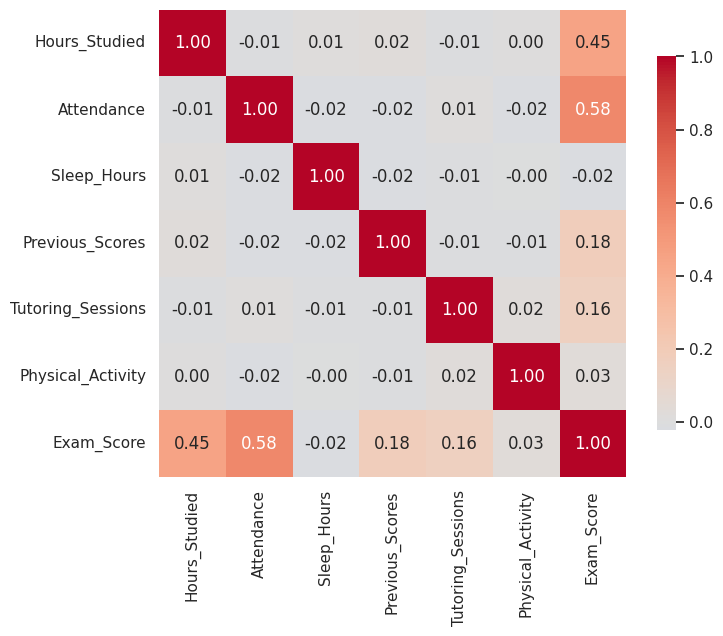


Correlation with Exam_Score:
Exam_Score           1.000
Attendance           0.581
Hours_Studied        0.445
Previous_Scores      0.175
Tutoring_Sessions    0.157
Physical_Activity    0.028
Sleep_Hours         -0.017
Name: Exam_Score, dtype: float64


In [10]:
# Correlation heatmap of the numerical variables
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, cbar_kws={"shrink": 0.8})
plt.tight_layout()
plt.show()

print("\nCorrelation with Exam_Score:")
print(corr["Exam_Score"].sort_values(ascending=False).round(3))

### <font color="blue">**4. Data Preparation & Preprocessing**</font>

<font color="orange">4.1 Data Cleaning</font>

In [11]:
# Create target classes
df["Performance"] = pd.qcut(
    df["Exam_Score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [12]:
# Check class distribution
df["Performance"].value_counts()

,count
Performance,
Low,2882
Medium,2100
High,1625


/tmp/ipykernel_3619/2818086835.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Performance", data=df, order=["Low", "Medium", "High"], palette="Blues_d")


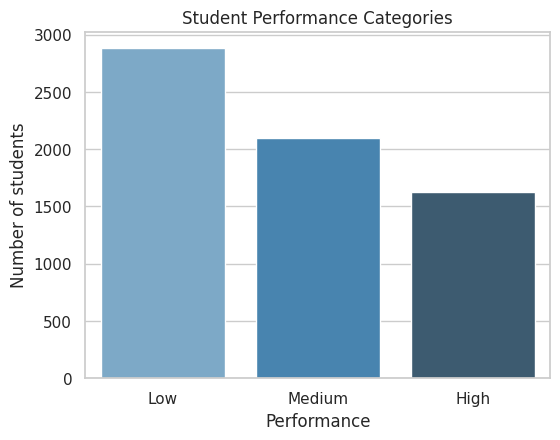

In [13]:
# Visualise the classes
plt.figure(figsize=(6, 4.5))
sns.countplot(x="Performance", data=df, order=["Low", "Medium", "High"], palette="Blues_d")
plt.title("Student Performance Categories")
plt.ylabel("Number of students")
plt.show()

In [14]:
# Removing old target column
df.drop("Exam_Score", axis=1, inplace=True)

In [15]:
# Checking the columns
print(df.columns)

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Performance'],
      dtype='object')


<font color="orange">4.2 Handling Missing Values</font>

In [16]:
#check missing values
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


<font color="orange">4.3 Encoding Categorical Data</font>

In [18]:
#Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [17]:
# Finding categorical columns
cat_cols = df.select_dtypes(include='object').columns

print(f"Number of categorical columns: {len(cat_cols)}\n")
print(cat_cols)

Number of categorical columns: 13

Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object')


In [20]:
# Convert the categorical variables to numerical
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [24]:
# Handling missing values- retained as a distinct category.
# LabelEncoder assigns NaN its own integer code instead of dropping or imputing.
for col in ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]:
    print(f"{col}:")
    print(df[col].value_counts().sort_index().to_string())
    print()

print(f"Total missing values remaining: {df.isnull().sum().sum()}")

Teacher_Quality:
Teacher_Quality
0    1947
1     657
2    3925
3      78

Parental_Education_Level:
Parental_Education_Level
0    1989
1    3223
2    1305
3      90

Distance_from_Home:
Distance_from_Home
0     658
1    1998
2    3884
3      67

Total missing values remaining: 0


In [21]:
# Verifying everything is numeric
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Hours_Studied               6607 non-null   int64   
 1   Attendance                  6607 non-null   int64   
 2   Parental_Involvement        6607 non-null   int64   
 3   Access_to_Resources         6607 non-null   int64   
 4   Extracurricular_Activities  6607 non-null   int64   
 5   Sleep_Hours                 6607 non-null   int64   
 6   Previous_Scores             6607 non-null   int64   
 7   Motivation_Level            6607 non-null   int64   
 8   Internet_Access             6607 non-null   int64   
 9   Tutoring_Sessions           6607 non-null   int64   
 10  Family_Income               6607 non-null   int64   
 11  Teacher_Quality             6607 non-null   int64   
 12  School_Type                 6607 non-null   int64   
 13  Peer_Influence    

In [22]:
# Encoding the target variable
df["Performance"] = LabelEncoder().fit_transform(df["Performance"])

In [23]:
# Checking class balance
print(df["Performance"].value_counts())

Performance
1    2882
2    2100
0    1625
Name: count, dtype: int64


<font color="orange">4.4 Feature Selection - Split the dtata & Feature scaling</font>

In [25]:
# Split feature and target
X = df.drop("Performance", axis=1)   # information used to make predictions
y = df["Performance"]                # what we want to predict

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6607, 19)
y shape: (6607,)


In [26]:
# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5285, 19)
Testing data: (1322, 19)


In [28]:
# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### <font color="blue">**5. Model Selection & Training**</font>
#### <font color="orange">1. Decision Tree</font> <font color="orange">2. Random Forest</font> <font color="orange">3. Support Vector Machine</font>

### <font color="orange">1. Decision Tree</font>

In [29]:
# Train the decision tree
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [30]:
# Make predictions
y_pred_dt = dt_model.predict(X_test)

In [31]:
# Check accuracy
accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy)

Decision Tree Accuracy: 0.68910741301059


In [32]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.78      0.66      0.72       325
           1       0.78      0.80      0.79       577
           2       0.52      0.56      0.54       420

    accuracy                           0.69      1322
   macro avg       0.69      0.67      0.68      1322
weighted avg       0.70      0.69      0.69      1322



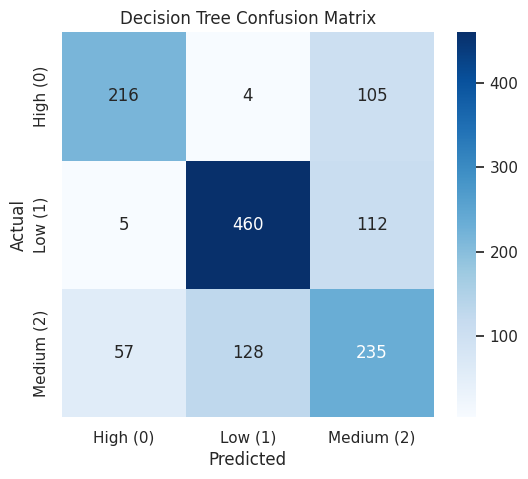

In [33]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["High (0)", "Low (1)", "Medium (2)"],
    yticklabels=["High (0)", "Low (1)", "Medium (2)"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

### <font color="orange">2. Random Forest</font>

In [35]:
# Train random forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=10
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [36]:
# Predictions
y_pred_rf = rf_model.predict(X_test)

In [37]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.791981845688351


In [38]:
# Classification report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.75      0.81       325
           1       0.83      0.90      0.86       577
           2       0.68      0.67      0.67       420

    accuracy                           0.79      1322
   macro avg       0.80      0.78      0.78      1322
weighted avg       0.79      0.79      0.79      1322



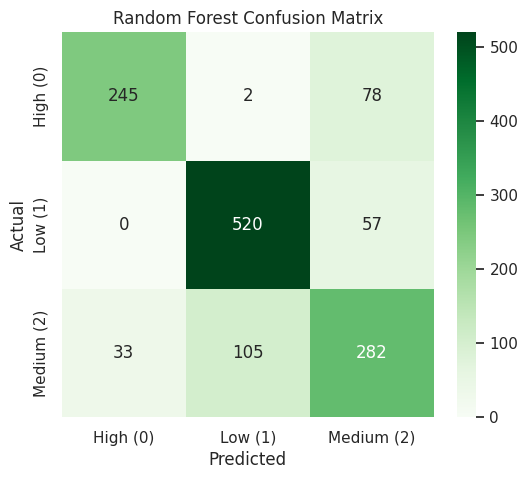

In [39]:
# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=["High (0)", "Low (1)", "Medium (2)"],
    yticklabels=["High (0)", "Low (1)", "Medium (2)"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

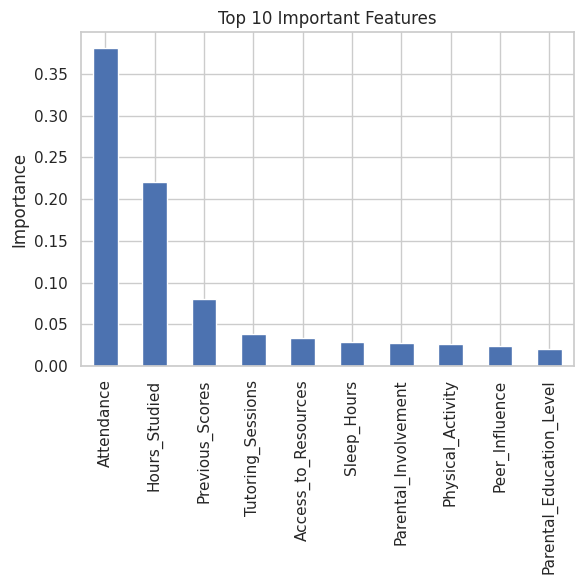

Attendance                  0.3806
Hours_Studied               0.2200
Previous_Scores             0.0804
Tutoring_Sessions           0.0390
Access_to_Resources         0.0340
Sleep_Hours                 0.0284
Parental_Involvement        0.0280
Physical_Activity           0.0260
Peer_Influence              0.0238
Parental_Education_Level    0.0207


In [45]:
# Feature importance
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).head(10).plot(kind='bar', figsize=(6, 6), color="#4C72B0")

plt.title("Top 10 Important Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

print(importance.sort_values(ascending=False).head(10).round(4).to_string())

### <font color="orange">3. Support Vector Machine</font>

In [46]:
# Train SVM
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [47]:
# Prediction
y_pred_svm = svm_model.predict(X_test_scaled)

In [48]:
# Accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.857034795763994


In [49]:
# Classification report
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.90      0.83      0.86       325
           1       0.91      0.90      0.91       577
           2       0.76      0.81      0.79       420

    accuracy                           0.86      1322
   macro avg       0.86      0.85      0.85      1322
weighted avg       0.86      0.86      0.86      1322



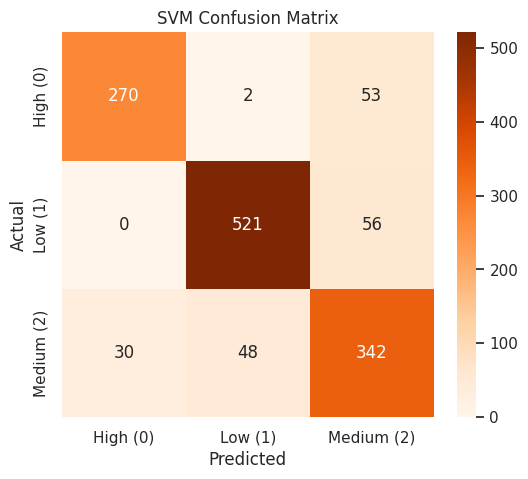

In [50]:
# Confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=["High (0)", "Low (1)", "Medium (2)"],
    yticklabels=["High (0)", "Low (1)", "Medium (2)"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.show()

In [54]:
# Comparison of Correct predictions per class across all three models
diagonal_table = pd.DataFrame(
    {
        "Tree": np.diag(cm),
        "Forest": np.diag(cm_rf),
        "SVM": np.diag(cm_svm)
    },
    index=["High correct", "Low correct", "Medium correct"]
)

print("Comparison of Correct predictions per class (confusion matrix diagonals)\n")
print(diagonal_table.to_string())

Comparison of Correct predictions per class (confusion matrix diagonals)

                Tree  Forest  SVM
High correct     216     245  270
Low correct      460     520  521
Medium correct   235     282  342


### <font color="blue">**6. Results & Model Evaluation**</font>

In [56]:
# Model comparison table
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "SVM (RBF)"],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        svm_accuracy
    ],
    "Macro F1": [
        f1_score(y_test, y_pred_dt, average="macro"),
        f1_score(y_test, y_pred_rf, average="macro"),
        f1_score(y_test, y_pred_svm, average="macro")
    ]
})

print(comparison.round(4).to_string(index=False))

        Model  Accuracy  Macro F1
Decision Tree    0.6891    0.6808
Random Forest    0.7920    0.7834
    SVM (RBF)    0.8570    0.8523


In [59]:
# Comparative performance on the 1,322-record test set
from sklearn.metrics import precision_score, recall_score

results = []
for name, preds in [("Decision Tree", y_pred_dt),
                    ("Random Forest", y_pred_rf),
                    ("SVM", y_pred_svm)]:
    results.append({
        "Model": name,
        "Accuracy": f"{accuracy_score(y_test, preds):.2%}",
        "Weighted Precision": round(precision_score(y_test, preds, average="weighted"), 2),
        "Weighted Recall": round(recall_score(y_test, preds, average="weighted"), 2),
        "Weighted F1-score": round(f1_score(y_test, preds, average="weighted"), 2)
    })

comparison_table = pd.DataFrame(results)
comparison_table

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1-score
0,Decision Tree,68.91%,0.70,0.69,0.69
1,Random Forest,79.20%,0.79,0.79,0.79
2,SVM,85.70%,0.86,0.86,0.86


In [57]:
# Compare against baseline: what accuracy would we get by always guessing "Low"?
baseline = df["Performance"].value_counts(normalize=True).max()

print(f"Majority-class baseline: {baseline:.2%}\n")
for name, acc in zip(comparison["Model"], comparison["Accuracy"]):
    print(f"{name:<15} {acc:.2%}   (+{(acc - baseline) * 100:.1f} points)")

Majority-class baseline: 43.62%

Decision Tree   68.91%   (+25.3 points)
Random Forest   79.20%   (+35.6 points)
SVM (RBF)       85.70%   (+42.1 points)


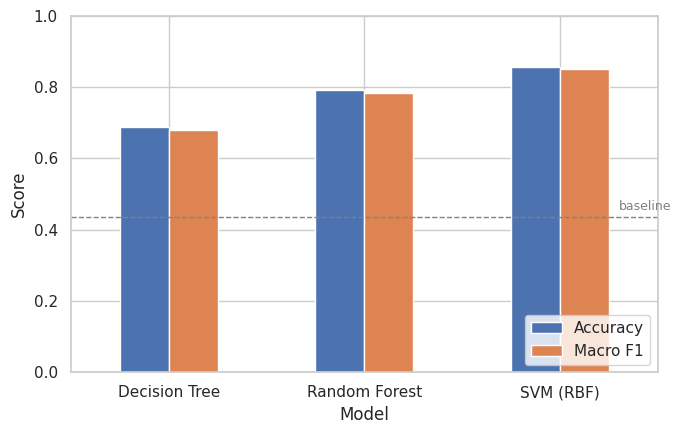

In [58]:
# Model comparison bar chart
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(7, 4.5),
    color=["#4C72B0", "#DD8452"],
    rot=0
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.axhline(baseline, color="grey", linestyle="--", linewidth=1)
plt.text(2.3, baseline + 0.02, "baseline", color="grey", fontsize=9)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### <font color="blue">**Findings & Conclusion**</font>

<font color="orange">The SVM with an RBF kernel is the best-performing model, achieving 85.70%
accuracy and a macro-F1 of 0.85, ahead of the Random Forest (79.20%, 0.78)
and the Decision Tree (68.91%, 0.68). All three exceed the 43.62%
majority-class baseline, confirming genuine learning.

<font color="orange">Performance improves consistently with model flexibility. The Decision Tree
is limited to axis-aligned splits, the Random Forest reduces variance by
averaging 200 such trees, and the SVM's RBF kernel fits a smooth non-linear
boundary. The largest gains appear on the Medium class, the narrow 67-69 mark
band where class boundaries are least distinct: F1 rises from 0.54 to 0.67 to
0.79 across the three models.</font>

<font color="orange">Attendance (0.381), Hours_Studied (0.220) and Previous_Scores (0.080) account
for approximately 68% of total feature importance, and no demographic
variable appears in the top three. The models therefore rely on behavioural
and prior-attainment factors instead of student background.</font>